<h1>1. Import Library</h1>

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import random
import os
current_path = os.getcwd()
print(current_path)
seed_value = 42

random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

os.environ['PYTHONHASHSEED'] = str(seed_value)

# from google.colab import drive
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import cv2


In [ ]:
Configs = {
    "dataset": f"{current_path}/CarTreeSatelliteDataset",
    "batch_size": 32,
    "img_size": 64,
    "hidden_layers": [512, 256, 128],
    "lr": 0.001,
    "epochs": 15,
    "saveWeightPath": f"{current_path}/best_model_tensorflow.h5"
}
print(Configs)

<h1>2. Review And Loading Data</h1>

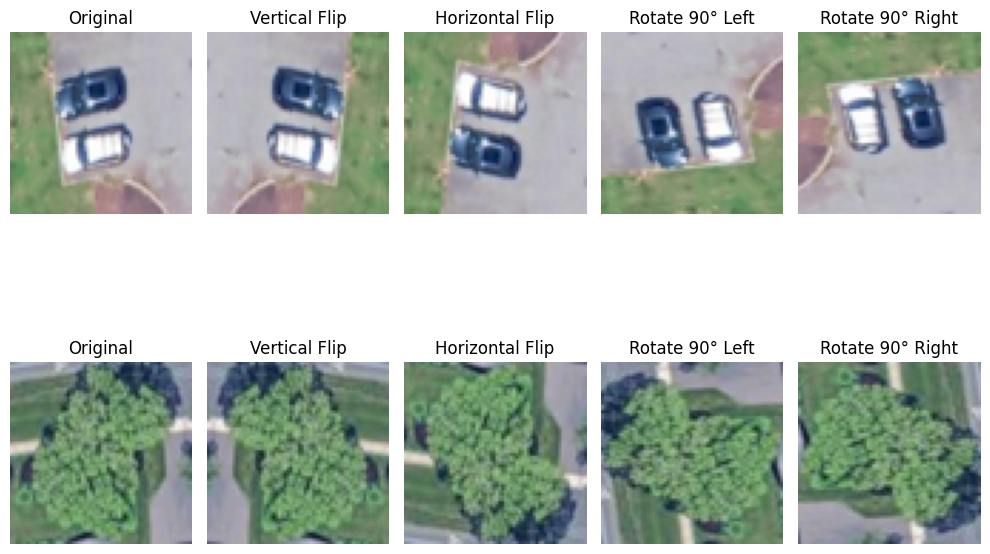

In [ ]:
carImg = Image.open(f"{Configs['dataset']}/train/cars/1.png").resize((Configs["img_size"], Configs["img_size"]))
carVFlip = Image.open(f"{Configs['dataset']}/train/cars/1+_VFlip.png").resize((Configs["img_size"], Configs["img_size"]))
carHFlip = Image.open(f"{Configs['dataset']}/train/cars/1+_HFlip.png").resize((Configs["img_size"], Configs["img_size"]))
car90RF = Image.open(f"{Configs['dataset']}/train/cars/1+rl90.png").resize((Configs["img_size"], Configs["img_size"]))
car90RR = Image.open(f"{Configs['dataset']}/train/cars/1+rr90.png").resize((Configs["img_size"], Configs["img_size"]))

treeImg = Image.open(f"{Configs['dataset']}/train/trees/1.png").resize((Configs["img_size"], Configs["img_size"]))
treeVFlip = Image.open(f"{Configs['dataset']}/train/trees/1+_VFlip.png").resize((Configs["img_size"], Configs["img_size"]))
treeHFlip = Image.open(f"{Configs['dataset']}/train/trees/1+_HFlip.png").resize((Configs["img_size"], Configs["img_size"]))
tree90RF = Image.open(f"{Configs['dataset']}/train/trees/1+rl90.png").resize((Configs["img_size"], Configs["img_size"]))
tree90RR = Image.open(f"{Configs['dataset']}/train/trees/1+rr90.png").resize((Configs["img_size"], Configs["img_size"]))
plt.figure(figsize=(10,8))

plt.subplot(2,5,1)
plt.imshow(carImg)
plt.title("Original")
plt.axis("off")

plt.subplot(2,5,2)
plt.imshow(carVFlip)
plt.title("Vertical Flip")
plt.axis("off")

plt.subplot(2,5,3)
plt.imshow(carHFlip)
plt.title("Horizontal Flip")
plt.axis("off")

plt.subplot(2,5,4)
plt.imshow(car90RF)
plt.title("Rotate 90° Left")
plt.axis("off")

plt.subplot(2,5,5)
plt.imshow(car90RR)
plt.title("Rotate 90° Right")
plt.axis("off")


plt.subplot(2,5,6)
plt.imshow(treeImg)
plt.title("Original")
plt.axis("off")

plt.subplot(2,5,7)
plt.imshow(treeVFlip)
plt.title("Vertical Flip")
plt.axis("off")

plt.subplot(2,5,8)
plt.imshow(treeHFlip)
plt.title("Horizontal Flip")
plt.axis("off")

plt.subplot(2,5,9)
plt.imshow(tree90RF)
plt.title("Rotate 90° Left")
plt.axis("off")

plt.subplot(2,5,10)
plt.imshow(tree90RR)
plt.title("Rotate 90° Right")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Load dataset
normalization_layer = layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{Configs['dataset']}/train",
    image_size=(Configs["img_size"], Configs["img_size"]),
    batch_size=Configs["batch_size"],
    shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{Configs['dataset']}/val",
    image_size=(Configs["img_size"], Configs["img_size"]),
    batch_size=Configs["batch_size"]
)
print(train_ds.class_names)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))


val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


Found 1600 files belonging to 2 classes.
Found 400 files belonging to 2 classes.
['cars', 'trees']


<h1>3. Setup Model</h1>

In [ ]:
myModel = models.Sequential()

myModel.add(layers.Flatten(input_shape=(Configs["img_size"], Configs["img_size"], 3)))

for units in Configs["hidden_layers"]:
    myModel.add(layers.Dense(units, activation='relu'))
    myModel.add(layers.Dropout(0.2))

myModel.add(layers.Dense(1, activation='sigmoid'))
print(myModel.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,321 (24.63 MB)

 Trainable params: 6,456,321 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

None


<h1>4. Setup training Strategies</h1>

In [ ]:
def lr_schedule(epoch, lr):
    next_lr = lr * 0.1
    if epoch % 4 == 0 and epoch > 0 and next_lr > 0:
        lr = next_lr
    return lr

myModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=Configs['lr']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_callback = ModelCheckpoint(
    Configs["saveWeightPath"],
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lr_schedule)
history = myModel.fit(
    train_ds,
    epochs=Configs["epochs"],
    validation_data=val_ds,
    callbacks=[lr_scheduler, checkpoint_callback],
    verbose=1
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5051 - loss: 2.1498
Epoch 1: val_accuracy improved from -inf to 0.59250, saving model to /content/drive/MyDrive/ColabNotebooks/ImageClassification_pytorch_n_tensorflow/best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.5058 - loss: 2.1368 - val_accuracy: 0.5925 - val_loss: 0.5587 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7137 - loss: 0.5308
Epoch 2: val_accuracy improved from 0.59250 to 0.74500, saving model to /content/drive/MyDrive/ColabNotebooks/ImageClassification_pytorch_n_tensorflow/best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7153 - loss: 0.5285 - val_accuracy: 0.7450 - val_loss: 0.5083 - learning_rate: 0.0010
Epoch 3/20
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9006 - loss: 0.2479
Epoch 3: val_accuracy improved from 0.74500 to 0.83250, saving model to /content/drive/MyDrive/ColabNotebooks/ImageClassification_pytorch_n_tensorflow/best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9013 - loss: 0.2463 - val_accuracy: 0.8325 - val_loss: 0.3304 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9728 - loss: 0.1052
Epoch 4: val_accuracy did not improve from 0.83250
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9726 - loss: 0.1057 - val_accuracy: 0.8050 - val_loss: 0.4542 - learning_rate: 0.0010
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9771 - loss: 0.0745
Epoch 5: val_accuracy did not improve from 0.83250
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9771 - loss: 0.0745 - val_accuracy: 0.8150 - val_loss: 0.4037 - learning_rate: 1.0000e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9835 - loss: 0.0553
Epoch 6: val_accuracy did not improve from 0.83250
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9835 - loss: 0.0555 - val_accuracy: 0.8325 - val_loss: 0.3835 - learning_rate: 1.0000e-04
Epoch 7/20
50/50 ━━━━━━━

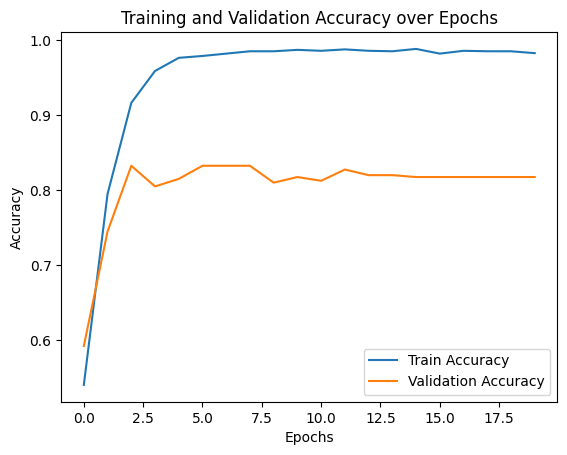

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()


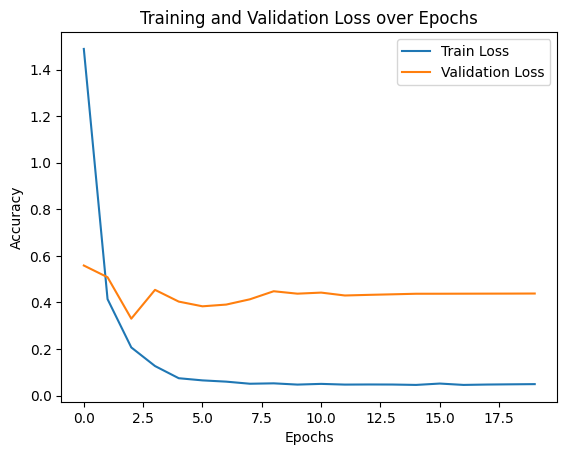

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


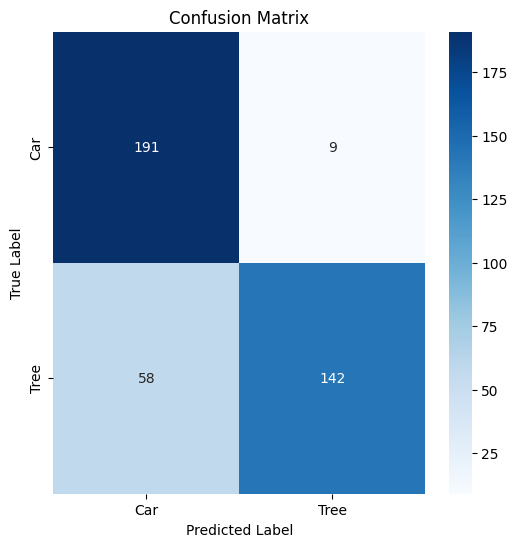

Classification Report:
              precision    recall  f1-score   support

         Car       0.77      0.95      0.85       200
        Tree       0.94      0.71      0.81       200

    accuracy                           0.83       400
   macro avg       0.85      0.83      0.83       400
weighted avg       0.85      0.83      0.83       400



In [ ]:
import tensorflow as tf

best_model_path = Configs["saveWeightPath"]
model = tf.keras.models.load_model(best_model_path)

y_true = []
y_pred = []

for images, labels in val_ds:
    images = images.numpy()
    labels = labels.numpy()
    y_true.extend(labels)

    preds = model.predict(images)
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Car', 'Tree'], yticklabels=['Car', 'Tree'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

report = classification_report(y_true, y_pred, target_names=['Car', 'Tree'])
print("Classification Report:")
print(report)



<h1>5. Real Test</h1>

In [ ]:
pathRealImages = os.path.join(Configs["dataset"], "realTest")

In [ ]:
real_images = []
real_labels = []
y_true = []
y_pred = []
testImagePaths = [os.path.join(Configs["dataset"], "realTest", x) for x in os.listdir(pathRealImages)]
print(f"total images for test: {len(testImagePaths)}")
# testImagePaths = [
#     "/content/drive/MyDrive/ColabNotebooks/CarTreeSatellite/realTest/car3.png",
#     "/content/drive/MyDrive/ColabNotebooks/CarTreeSatellite/realTest/car2.png",
#     "/content/drive/MyDrive/ColabNotebooks/CarTreeSatellite/realTest/tree1.png",
#     "/content/drive/MyDrive/ColabNotebooks/CarTreeSatellite/realTest/tree4.png",
#     ]
for path in testImagePaths:
  img = cv2.imread(path)[:,:,::-1]  # Convert BGR to RGB
  img_resized = cv2.resize(img, (Configs["img_size"], Configs["img_size"]))

  img_resized = img_resized / 255.0

  img_resized = np.expand_dims(img_resized, axis=0)  # Shape (1, 64, 64, 3)

  real_images.append(img_resized)

  y_true.append(1 if "/tree" in path else 0)

  preds = model.predict(img_resized)
  y_pred.append((preds > 0.5).astype(int))  # Convert probabilities to 0/1



total images for test: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


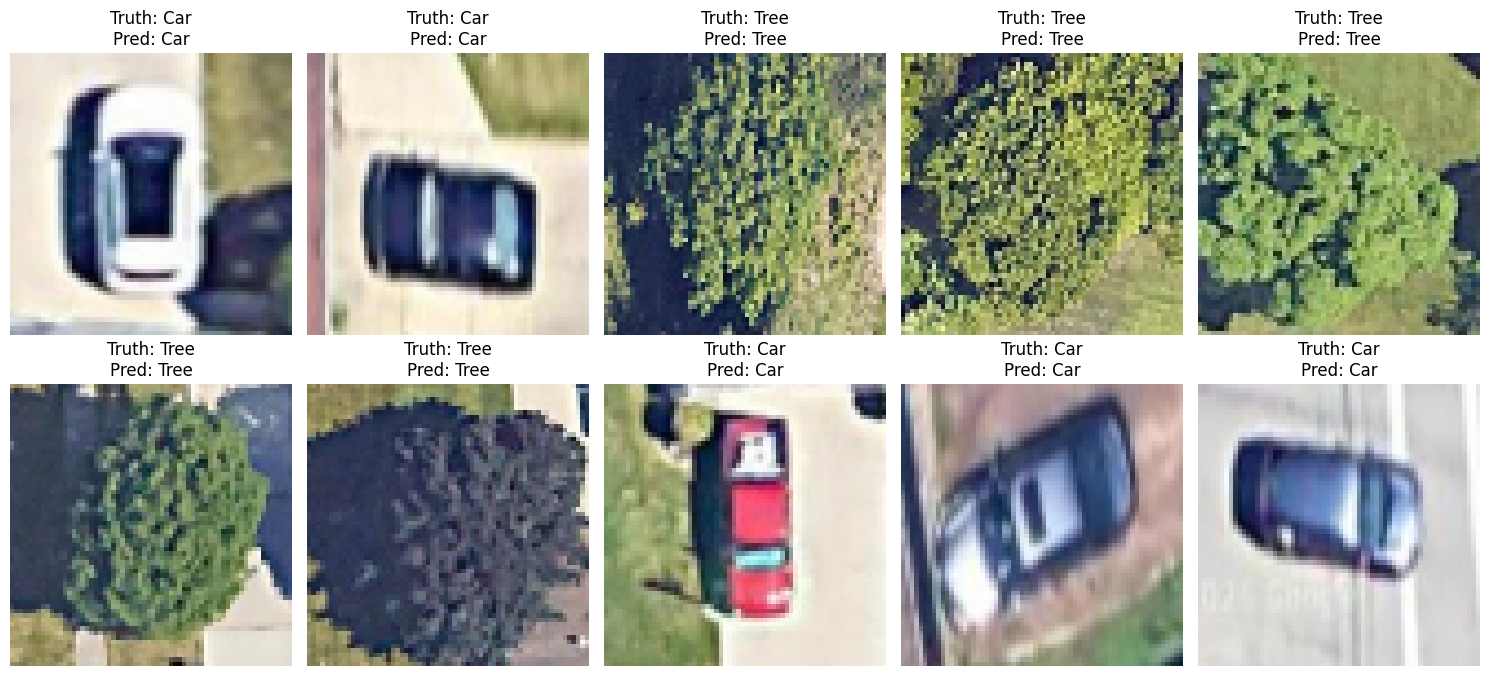

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


num_images_to_display = 10
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

axes = axes.flatten()

for i in range(num_images_to_display):
    ax = axes[i]

    img = real_images[i][0]
    true_label = 'Tree' if y_true[i] == 1 else 'Car'
    pred_label = 'Tree' if y_pred[i] == 1 else 'Car'

    # Display image
    ax.imshow(img)
    ax.set_title(f"Truth: {true_label}\nPred: {pred_label}")
    ax.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# /content/drive/MyDrive/ColabNotebooks/CarTreeSatellite/val/cars/159.png